In [ ]:
from cosipy import BinnedData, UnBinnedData#, COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from lmfit import Model as lmfitModel
from lmfit.models import GaussianModel

from threeML import Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

In [2]:
DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')

In [4]:
name = 'CasAsymmetric'
source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')

this_dict = source.get_dict_from_fits(source.data_file)

In [5]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth.ori'
target_coord = SkyCoord.from_name('Cas A').galactic
ori_SAA = SpacecraftFile.parse_from_file(ori_path.parent / (ori_path.stem + '_SAA.ori'))
scatt_map_SAA = ori_SAA.get_scatt_map(nside = 16, coordsys = 'galactic')

In [6]:
hist_SAA = Histogram.open('psr_scatt_SAA_hist.h5')

psr_SAA = PointSourceResponse(hist_SAA.axes[2:],
                              contents=hist_SAA.project('Phi', 'PsiChi').contents,
                              sparse=hist_SAA._sparse,
                              unit=hist_SAA.unit)

In [14]:
tiny = 1e-15
s2 = np.sqrt(2)

from lmfit.models import ConstantModel, LinearModel, StepModel
from scipy.special import erf
from matplotlib.offsetbox import AnchoredText

def fwhm_resolution(xprime):
    return 151.442 * xprime**(0.1) / 100

def expgaussianleft(x, amplitude=1, center=0, sigma=1.0, gamma=1.0):
    gss = -gamma*sigma*sigma
    arg1 = -gamma*(center + gss/2.0 - x)
    arg2 = (center + gss - x)/max(tiny, (s2*sigma))
    return amplitude*(gamma/2) * np.exp(arg1) * (erf(arg2) + 1)

def get_window_spectra_with_step(counts, bincenters, mu, sigmavary=True):
    model = lmfitModel(func=expgaussianleft, prefix='sig_') + ConstantModel(prefix='bg_') + StepModel(prefix='step_', form='erf')
    params = model.make_params()

    params['sig_amplitude'].set(value=np.max(counts), min=0, max=1e6)   # A = sig_amplitude / sqrt(2pi) / sigma
    params['sig_center'].set(value=mu, min=mu-1.5, max=mu+1.5, vary=True)
    params['sig_sigma'].set(value=fwhm_resolution(mu)/2.355, max=4.5, vary=sigmavary)
    params['sig_gamma'].set(value=1.0, max=2.0)     # gamma = 1/tau

    params['bg_c'].set(value=np.mean(counts[:10]) - np.mean(counts[-10:]), min=0, vary=False)      # bg_c should be the left asymptote (as step amplitude is negative)
    params['step_amplitude'].set(value=-np.mean(counts[:10]), min=-np.inf, max=0, vary=False)      # Sum of bg_c and step_amplitude should be the right asymptote
    params['step_center'].set(expr='sig_center')    # See Equation 3 in Lonjou 2005
    params['step_sigma'].set(expr='sig_sigma')

    result = model.fit(counts, params, x=bincenters, scale_covar=False, 
                    #    weights=1/np.amax([np.sqrt(counts), np.ones(len(counts))], axis=0)
                       )

    return result

def plot_line_with_step(result, pn=None):
    bincenters = result.userkws['x']
    counts = result.data
    comps = result.eval_components(x=bincenters)
    dely = result.eval_uncertainty(sigma=1)
    dely_comps = result.dely_comps

    yval = result.best_fit
    uncertainty = dely
    plt.plot(bincenters, yval, '-', label='Best fit')
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    yval = comps['sig_']
    uncertainty = dely_comps['sig_']
    plt.plot(bincenters, yval, label=f"Signal {np.sum(yval):.0f} $\\pm$ {np.sum(dely_comps['sig_']):.0f}")
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    yval = comps['bg_'] + comps['step_']
    uncertainty = np.sqrt(dely_comps['bg_']**2 + dely_comps['step_']**2)
    plt.plot(bincenters, yval, 
             label=f"Bg {np.sum(yval):.0f} $\\pm$ {np.sum(np.sqrt(dely_comps['bg_']**2 + dely_comps['step_']**2)):.0f}")
    plt.fill_between(bincenters, yval - 3*uncertainty, yval + 3*uncertainty, alpha=0.1)

    plt.step(bincenters, counts, alpha=0.4, lw=1, c='c')
    plt.plot([], [], c='w')

    if pn is None:
        plt.title('Both strip sides with 3-$\\mathrm{\\sigma}$ uncertainty bands')
    else:
        plt.title(f'L05: {pn}-side with 3-$\\mathrm{{\\sigma}}$ uncertainty bands')
    
    at = AnchoredText(f"$\\mathrm{{\\mu}}$ = {result.values['sig_center']:.2f} $\\pm$ {result.params['sig_center'].stderr:.2f} keV\
                      \nFWHM = {result.values['sig_sigma']*2.355:.2f} $\\pm$ {result.params['sig_sigma'].stderr*2.355:.2f} keV\
                      \n$\\mathrm{{\\chi_r}}$² = {result.redchi:.2f}",
                      loc='upper left', prop={'size':14}, frameon=False)
    plt.gca().add_artist(at)

    plt.minorticks_on()
    # plt.yscale('log')
    # plt.ylim(bottom=0.9)
    plt.legend(fontsize=14)
    plt.show()

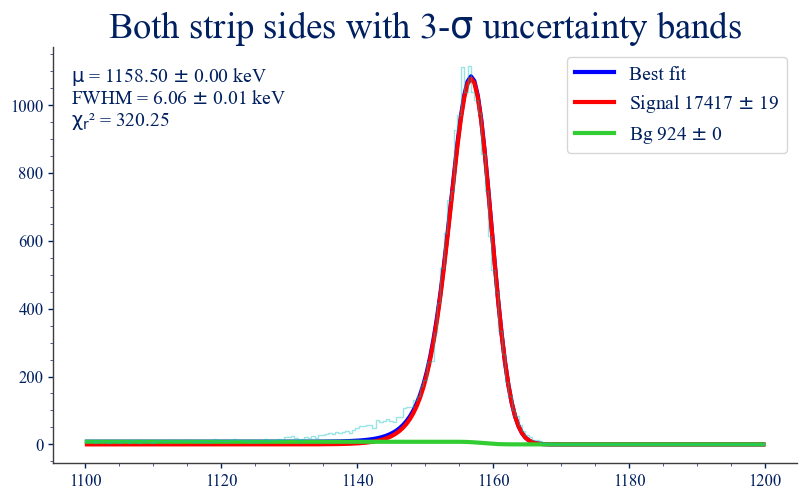

In [15]:
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1100, 1200, 201))

result = get_window_spectra_with_step(counts, (bins[1:]+bins[:-1])/2, 1157)
plot_line_with_step(result)

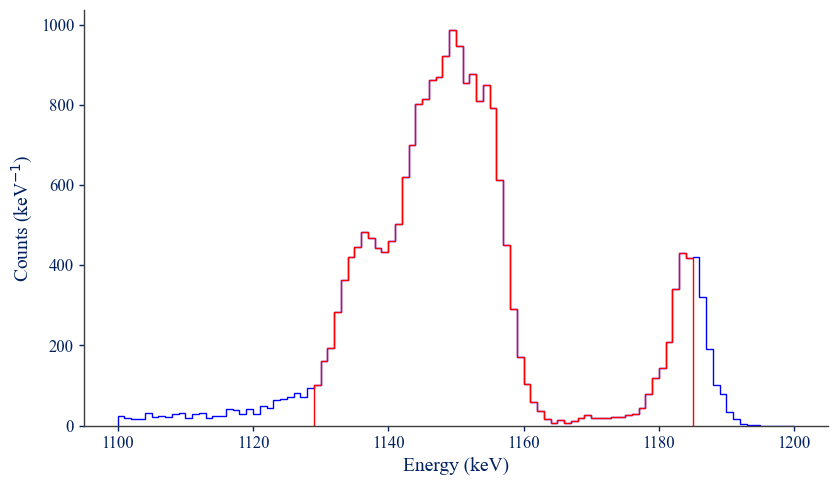

In [23]:
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1100, 1200, 101))
plt.stairs(counts / np.diff(bins), bins)
counts, bins = np.histogram(this_dict['Energies'], bins=np.linspace(1129, 1185, 57))
plt.stairs(counts / np.diff(bins), bins)
plt.ylabel('Counts (keV$^{-1}$)')
plt.xlabel('Energy (keV)')
plt.show()

In [27]:
bincenters = (bins[:-1] + bins[1:]) / 2
model = GaussianModel(prefix='g1_') + GaussianModel(prefix='g2_') + GaussianModel(prefix='g3_')

params = model.make_params()

params['g1_amplitude'].set(value = 1e3, min=1e2, max=1e4)
params['g1_center'].set(value = 1157, min=1136, max=1178)
params['g1_sigma'].set(value = 5, min=0, max=10)

params['g2_amplitude'].set(value = 1e3, min=1e2, max=1e4)
params['g2_center'].set(value = 1157, min=1136, max=1178)
params['g2_sigma'].set(value = 5, min=0, max=10)

params['g3_amplitude'].set(value = 1e3, min=1e2, max=1e4)
params['g3_center'].set(value = 1157, min=1136, max=1178)
params['g3_sigma'].set(value = 5, min=0, max=10)

result = model.fit(counts, params, x=bincenters, scale_covar=False, )
                #    weights=1/np.amax([np.sqrt(counts), np.ones(len(counts))], axis=0)

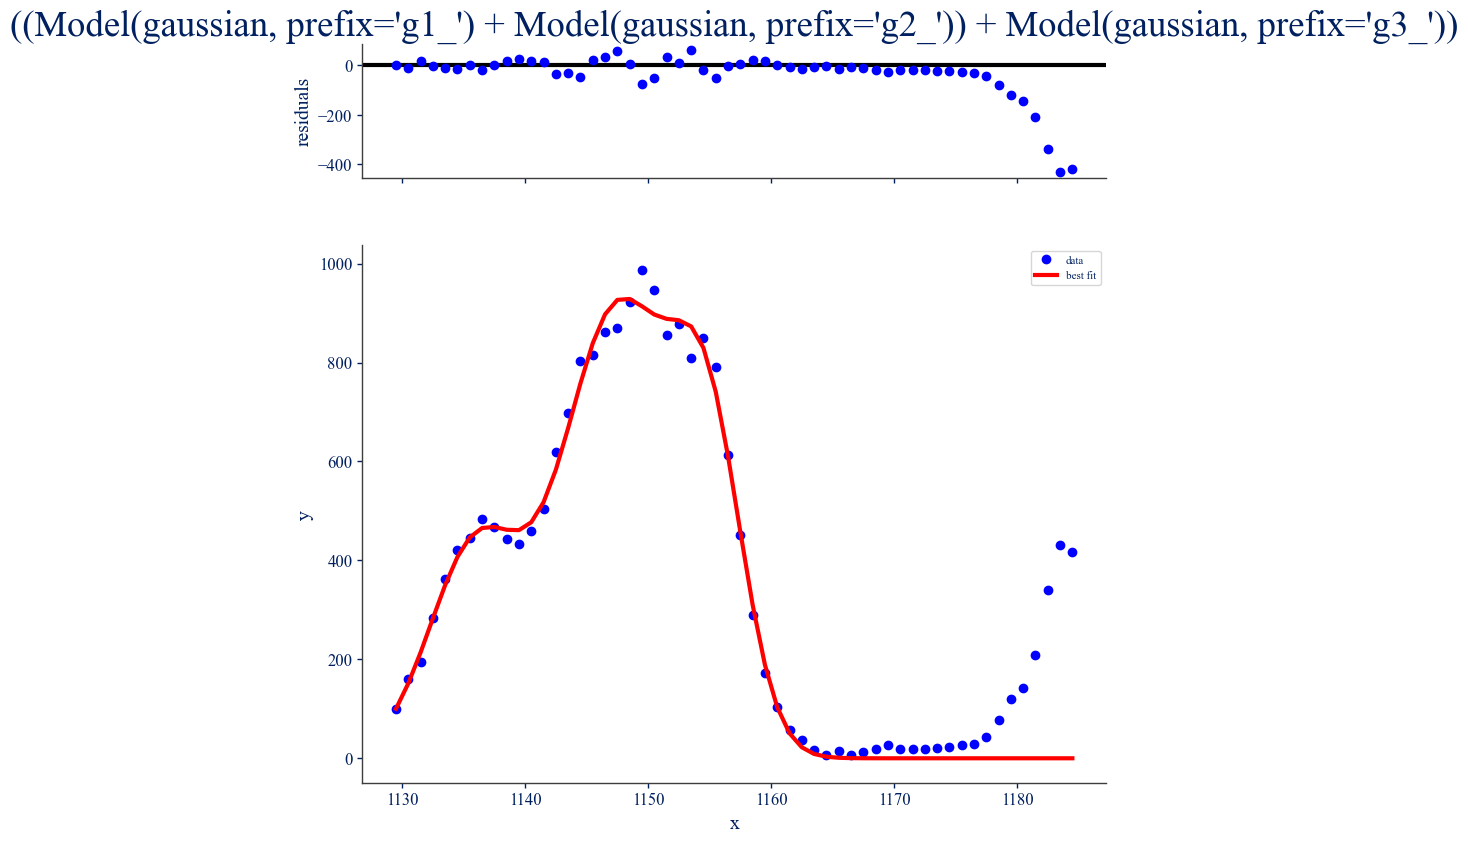

In [28]:
result.plot()
plt.show()